#01 · Benchmark Analysis

Analysis of the results of the `01_benchmark/` module — comparison of prompting strategies (zero-shot, few-shot, chain-of-thought) in the MMLU and HumanEval datasets.

**Metrics analyzed:** Accuracy, BLEU, ROUGE-L, LLM-as-judge score
**Input:** `01_benchmark/results/*.json`
**Output:** Comparative graphs + final ranking table

In [20]:
import json
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

RESULTS_DIR = Path('../scripts/results')
print('Arquivos encontrados:', list(RESULTS_DIR.glob('*.json')))

Arquivos encontrados: [WindowsPath('../scripts/results/zero_shot_qwen3-coder-480b-cloud.json')]


## 1 · Loading results

In [21]:
records = []
for path in sorted(RESULTS_DIR.glob('*.json')):
    with open(path) as f:
        data = json.load(f)
    # Suporta tanto lista quanto objeto único
    items = data if isinstance(data, list) else [data]
    records.extend(items)

df = pd.DataFrame(records)
print(f'{len(df)} resultados carregados')
df.head()

10 resultados carregados


,question,expected,predicted,strategy,model,latency_ms,bleu,rouge1,rouge2,rougeL,judge_score,judge_reason,judge_correct
0,Solve for $x$:$$\left(\frac{1}{25}\right)^{x +...,D,B,zero_shot,qwen3-coder:480b-cloud,1672.0,0.0000,0.0000,0.0,0.0000,1,The model answer is incorrect. The correct ans...,False
1,Let f(x) be a function whose graph passes thro...,B,B,zero_shot,qwen3-coder:480b-cloud,829.0,0.1778,1.0000,0.0,1.0000,5,The model answer correctly identifies the answ...,True
2,Statement 1 | A factor group of a non-Abelian ...,B,"D) False, True",zero_shot,qwen3-coder:480b-cloud,766.0,0.0000,0.0000,0.0,0.0000,5,The model answer correctly evaluates both stat...,True
3,Mill claims that one of the strongest objectio...,B,B) justice.,zero_shot,qwen3-coder:480b-cloud,797.0,0.0000,0.6667,0.0,0.6667,5,The model answer is fully correct and complete...,True
4,A student is experimenting with a simple sprin...,A,A,zero_shot,qwen3-coder:480b-cloud,719.0,0.1778,1.0000,0.0,1.0000,5,The model answer correctly identifies the answ...,True


## 2 · Accuracy by strategy and dataset

C:\Users\otnie\AppData\Local\Temp\ipykernel_9644\993746148.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


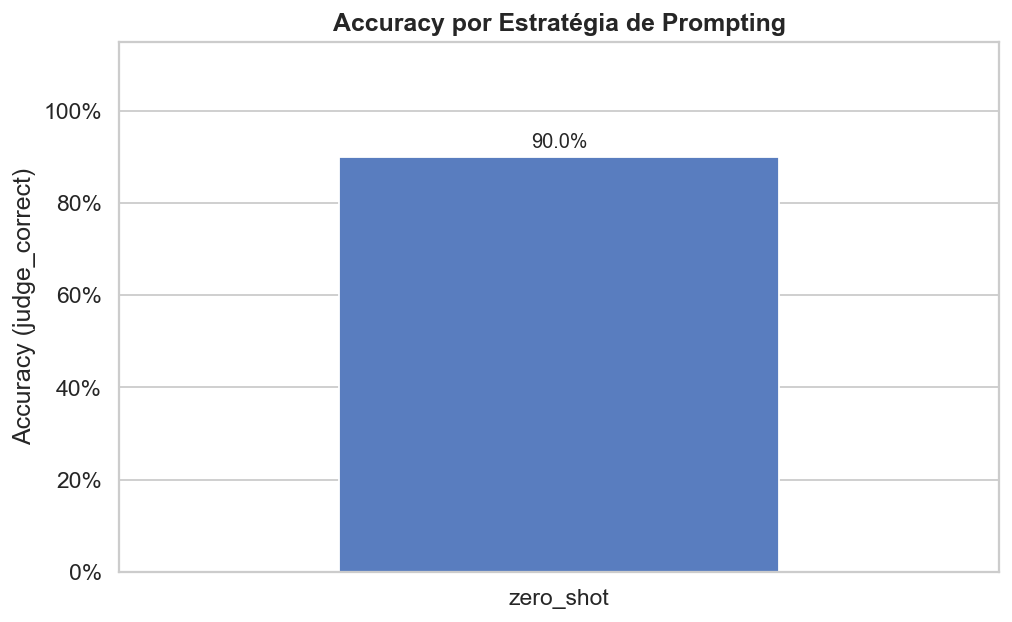

In [22]:
from matplotlib.container import BarContainer

acc = (
    df.groupby('strategy')['judge_correct']
    .mean()
    .reset_index()
    .rename(columns={'judge_correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=acc, x='strategy', y='accuracy',
    ax=ax, width=0.5, palette='muted'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.15)
ax.set_title('Accuracy por Estratégia de Prompting', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Accuracy (judge_correct)')

# Cast explícito para BarContainer — elimina aviso do Pylance
bar_container = next(c for c in ax.containers if isinstance(c, BarContainer))
ax.bar_label(bar_container, fmt='{:.1%}', padding=3, fontsize=11)

plt.tight_layout()
plt.savefig('benchmark_accuracy.png', bbox_inches='tight')
plt.show()

## 3 · ROUGE-L by strategy

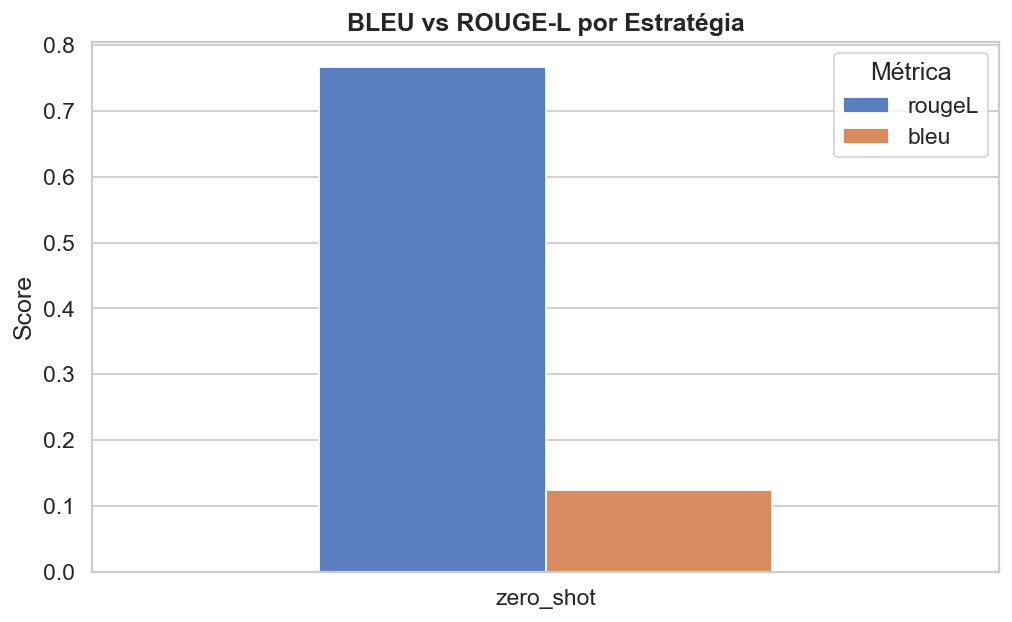

In [23]:
rouge = (
    df.groupby('strategy')[['rougeL', 'bleu']]
    .mean()
    .reset_index()
    .melt(id_vars='strategy', var_name='metric', value_name='score')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rouge, x='strategy', y='score', hue='metric', ax=ax, width=0.5)
ax.set_title('BLEU vs ROUGE-L por Estratégia', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(title='Métrica')
plt.tight_layout()
plt.savefig('benchmark_rouge_bleu.png', bbox_inches='tight')
plt.show()

## 4 · LLM-as-judge score distribution

C:\Users\otnie\AppData\Local\Temp\ipykernel_9644\1808257179.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


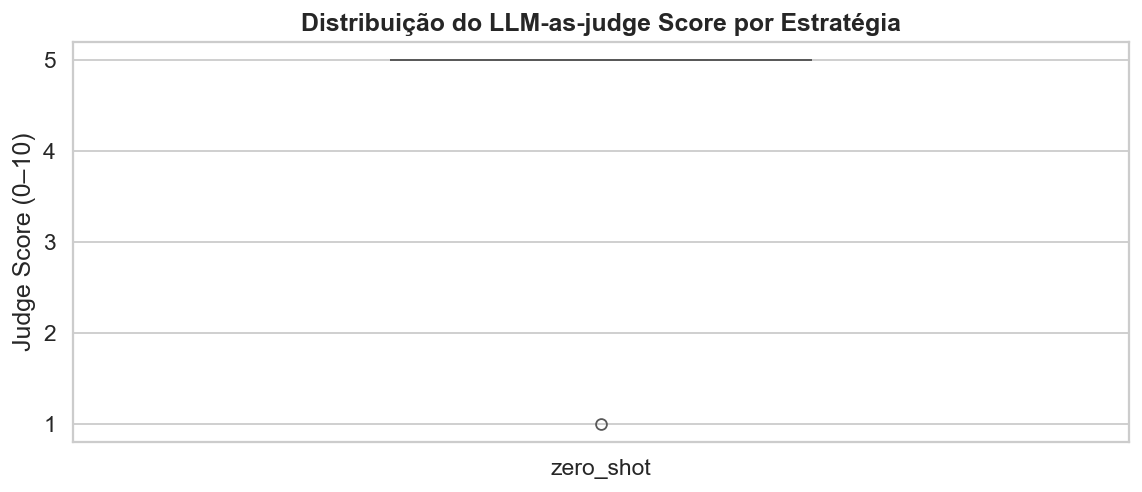

In [24]:
if 'judge_score' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(
        data=df, x='strategy', y='judge_score',
        ax=ax, width=0.4, palette='Set2'
    )
    ax.set_title('Distribuição do LLM-as-judge Score por Estratégia', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Judge Score (0–10)')
    plt.tight_layout()
    plt.savefig('benchmark_judge.png', bbox_inches='tight')
    plt.show()
else:
    print('Coluna judge_score não encontrada — rode evaluator.py com --judge para habilitar.')

## 5 · Consolidated final ranking

In [27]:
metrics = [c for c in ['judge_correct', 'rougeL', 'bleu', 'judge_score'] if c in df.columns]

ranking = (
    df.groupby('strategy')[metrics]
    .mean()
    .round(4)
    .sort_values('judge_correct', ascending=False)
    .rename(columns={
        'judge_correct': 'Accuracy',
        'rougeL': 'ROUGE-L',
        'bleu': 'BLEU',
        'judge_score': 'Judge Score',
    })
)

ranking.style \
    .background_gradient(cmap='Greens', axis=0) \
    .format(precision=4) \
    .set_caption('Ranking Final — médias por estratégia')

,Accuracy,ROUGE-L,BLEU,Judge Score
strategy,,,,
zero_shot,0.9000,0.7667,0.1245,4.6000


## 6 · Conclusions

Preencha após executar o benchmark completo:

- **Melhor estratégia geral:** `...`
- **Melhor estratégia para HumanEval:** `...`
- **Trade-off observado:** CoT melhora reasoning mas aumenta tokens ~3×
- **Próximos passos:** testar self-consistency (votação majoritária sobre N runs de CoT)